In [ ]:
import pandas as pd

comp = pd.read_csv('ablation_results/ablation_comparison.csv')

SCENARIO_LABELS = {
    '1_base_model': 'No glucose\n(all glucose vars removed)',
    '2_cgm_only_remove_labs': 'CGM only (Glucose + HbA1c)',
    '3_labs_only_remove_cgm': 'Glucose + HbA1c only\n(CGM removed)',
    '4_labs_plus_cgm': 'Glucose + HbA1c + CGM\n(tir, cv_glucose added)',
}

def fmt(r2, se):
    return f'{r2:.3f} \u00b1 {se:.3f}'

comp['ElasticNet R2 (\u00b1 SE)'] = [fmt(r, s) for r, s in zip(comp['enet_r2'], comp['enet_r2_se'])]
comp['XGBoost R2 (\u00b1 SE)'] = [fmt(r, s) for r, s in zip(comp['xgb_r2'], comp['xgb_r2_se'])]
comp['scenario_label'] = comp['scenario'].map(SCENARIO_LABELS)

pretty = comp.pivot(index='study_group', columns='scenario_label',
                     values=['ElasticNet R2 (\u00b1 SE)', 'XGBoost R2 (\u00b1 SE)'])
pretty = pretty.reindex(columns=list(SCENARIO_LABELS.values()), level=1)
pretty

ElasticNet R2 (± SE)  \
scenario_label                                     No glucose\n(all glucose vars removed)   
study_group                                                                                 
healthy                                                                     0.738 ± 0.041   
insulin_dependent                                                           0.072 ± 0.165   
oral_medication_and_or_non_insulin_injectable_m...                          0.714 ± 0.039   
pre_diabetes_lifestyle_controlled                                           0.716 ± 0.071   

                                                                               \
scenario_label                                     CGM only (Glucose + HbA1c)   
study_group                                                                     
healthy                                                         0.736 ± 0.042   
insulin_dependent                                               0.104 ± 0.161   
oral_medication_and_or_non_insulin_injectable_m...              0.714 ± 0.039   
pre_diabetes_lifestyle_controlled                               0.717 ± 0.069   

                                                                                        \
scenario_label                                     Glucose + HbA1c only\n(CGM removed)   
study_group                                                                              
healthy                                                                  0.755 ± 0.044   
insulin_dependent                                                        0.095 ± 0.162   
oral_medication_and_or_non_insulin_injectable_m...                       0.715 ± 0.038   
pre_diabetes_lifestyle_controlled                                        0.712 ± 0.080   

                                                                                                   \
scenario_label                                     Glucose + HbA1c + CGM\n(tir, cv_glucose added)   
study_group                                                                                         
healthy                                                                             0.753 ± 0.044   
insulin_dependent                                                                   0.103 ± 0.163   
oral_medication_and_or_non_insulin_injectable_m...                                  0.711 ± 0.038   
pre_diabetes_lifestyle_controlled                                                   0.710 ± 0.078   

                                                                        XGBoost R2 (± SE)  \
scenario_label                                     No glucose\n(all glucose vars removed)   
study_group                                                                                 
healthy                                                                     0.730 ± 0.047   
insulin_dependent                                                           0.155 ± 0.122   
oral_medication_and_or_non_insulin_injectable_m...                          0.756 ± 0.063   
pre_diabetes_lifestyle_controlled                                           0.632 ± 0.090   

                                                                               \
scenario_label                                     CGM only (Glucose + HbA1c)   
study_group                                                                     
healthy                                                         0.701 ± 0.067   
insulin_dependent                                               0.168 ± 0.121   
oral_medication_and_or_non_insulin_injectable_m...              0.756 ± 0.059   
pre_diabetes_lifestyle_controlled                               0.641 ± 0.085   

                                                                                        \
scenario_label                                     Glucose + HbA1c only\n(CGM removed)   
study_group                                                                              
healthy             

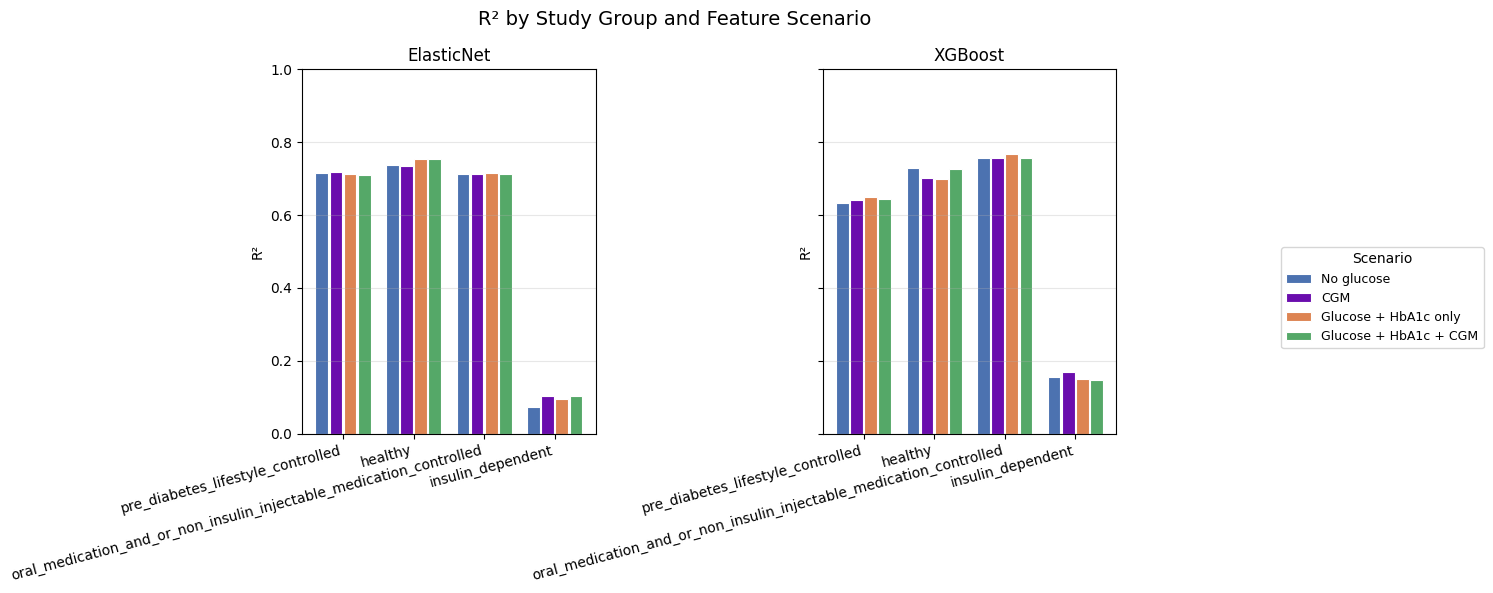

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

comp = pd.read_csv('ablation_results/ablation_comparison.csv')

SCENARIO_LABELS = {
    '1_no_glucose': 'base_model',
    '2_cgm_only_remove_labs': 'CGM',
    '3_labs_only_remove_cgm': 'Glucose + HbA1c only',
    '4_labs_plus_cgm': 'Glucose + HbA1c + CGM',
}
comp['scenario_label'] = comp['scenario'].map(SCENARIO_LABELS)

study_groups = comp['study_group'].unique()
scenarios = list(SCENARIO_LABELS.values())
color_map = dict(zip(scenarios, ['#4C72B0', '#6A0DAD', '#DD8452', '#55A868']))

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

n_scenarios = len(scenarios)
group_width = 0.8
bar_width = group_width / n_scenarios

for ax, model, r2_col, se_col in zip(
    axes,
    ['ElasticNet', 'XGBoost'],
    ['enet_r2', 'xgb_r2'],
    ['enet_r2_se', 'xgb_r2_se']
):
    x = np.arange(len(study_groups))

    # dodge bars side-by-side per scenario so every color stays fully visible,
    # even when R2 values are nearly identical across scenarios
    for i, scenario in enumerate(scenarios):
        offset = (i - (n_scenarios - 1) / 2) * bar_width
        sub = comp[comp['scenario_label'] == scenario].set_index('study_group').reindex(study_groups)
        ax.bar(
            x + offset, sub[r2_col], width=bar_width * 0.9,
            color=color_map[scenario],
            edgecolor='white', linewidth=0.8,
            label=scenario
        )

    ax.set_xticks(x)
    ax.set_xticklabels(study_groups, rotation=15, ha='right')
    ax.set_ylim(0, 1)
    ax.set_ylabel('R²')
    ax.set_title(model)
    ax.grid(axis='y', alpha=0.3, zorder=0)

# shared legend, placed outside the plotting area
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    title='Scenario',
    loc='center left',
    bbox_to_anchor=(1.0, 0.5),
    fontsize=9
)

plt.suptitle('R² by Study Group and Feature Scenario', fontsize=14)
plt.tight_layout(rect=[0, 0, 0.88, 1])
plt.savefig('ablation_results/r2_comparison_overlap.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
import pandas as pd

comp = pd.read_csv('ablation_results_minimal/ablation_comparison.csv')

SCENARIO_LABELS = {
    '1_base_model': 'No glucose\n(all glucose vars removed)',
    '2_cgm_only_remove_labs': 'CGM only (Glucose + HbA1c)',
    '3_labs_only_remove_cgm': 'Glucose + HbA1c only\n(CGM removed)',
    '4_labs_plus_cgm': 'Glucose + HbA1c + CGM\n(tir, cv_glucose added)',
}

def fmt(r2, se):
    return f'{r2:.3f} \u00b1 {se:.3f}'

comp['ElasticNet R2 (\u00b1 SE)'] = [fmt(r, s) for r, s in zip(comp['enet_r2'], comp['enet_r2_se'])]
comp['XGBoost R2 (\u00b1 SE)'] = [fmt(r, s) for r, s in zip(comp['xgb_r2'], comp['xgb_r2_se'])]
comp['scenario_label'] = comp['scenario'].map(SCENARIO_LABELS)

pretty = comp.pivot(index='study_group', columns='scenario_label',
                     values=['ElasticNet R2 (\u00b1 SE)', 'XGBoost R2 (\u00b1 SE)'])
pretty = pretty.reindex(columns=list(SCENARIO_LABELS.values()), level=1)
pretty

ElasticNet R2 (± SE)  \
scenario_label                                     No glucose\n(all glucose vars removed)   
study_group                                                                                 
healthy                                                                     0.054 ± 0.035   
insulin_dependent                                                           0.090 ± 0.085   
oral_medication_and_or_non_insulin_injectable_m...                          0.122 ± 0.023   
pre_diabetes_lifestyle_controlled                                           0.090 ± 0.055   

                                                                               \
scenario_label                                     CGM only (Glucose + HbA1c)   
study_group                                                                     
healthy                                                         0.055 ± 0.028   
insulin_dependent                                               0.108 ± 0.074   
oral_medication_and_or_non_insulin_injectable_m...              0.122 ± 0.023   
pre_diabetes_lifestyle_controlled                               0.096 ± 0.050   

                                                                                        \
scenario_label                                     Glucose + HbA1c only\n(CGM removed)   
study_group                                                                              
healthy                                                                  0.237 ± 0.047   
insulin_dependent                                                        0.089 ± 0.078   
oral_medication_and_or_non_insulin_injectable_m...                       0.234 ± 0.054   
pre_diabetes_lifestyle_controlled                                        0.038 ± 0.283   

                                                                                                   \
scenario_label                                     Glucose + HbA1c + CGM\n(tir, cv_glucose added)   
study_group                                                                                         
healthy                                                                             0.243 ± 0.054   
insulin_dependent                                                                   0.099 ± 0.076   
oral_medication_and_or_non_insulin_injectable_m...                                  0.240 ± 0.045   
pre_diabetes_lifestyle_controlled                                                   0.051 ± 0.239   

                                                                        XGBoost R2 (± SE)  \
scenario_label                                     No glucose\n(all glucose vars removed)   
study_group                                                                                 
healthy                                                                     0.025 ± 0.025   
insulin_dependent                                                           0.159 ± 0.177   
oral_medication_and_or_non_insulin_injectable_m...                          0.080 ± 0.039   
pre_diabetes_lifestyle_controlled                                           0.078 ± 0.038   

                                                                               \
scenario_label                                     CGM only (Glucose + HbA1c)   
study_group                                                                     
healthy                                                         0.031 ± 0.021   
insulin_dependent                                               0.192 ± 0.099   
oral_medication_and_or_non_insulin_injectable_m...              0.114 ± 0.047   
pre_diabetes_lifestyle_controlled                               0.081 ± 0.044   

                                                                                        \
scenario_label                                     Glucose + HbA1c only\n(CGM removed)   
study_group                                                                              
healthy             

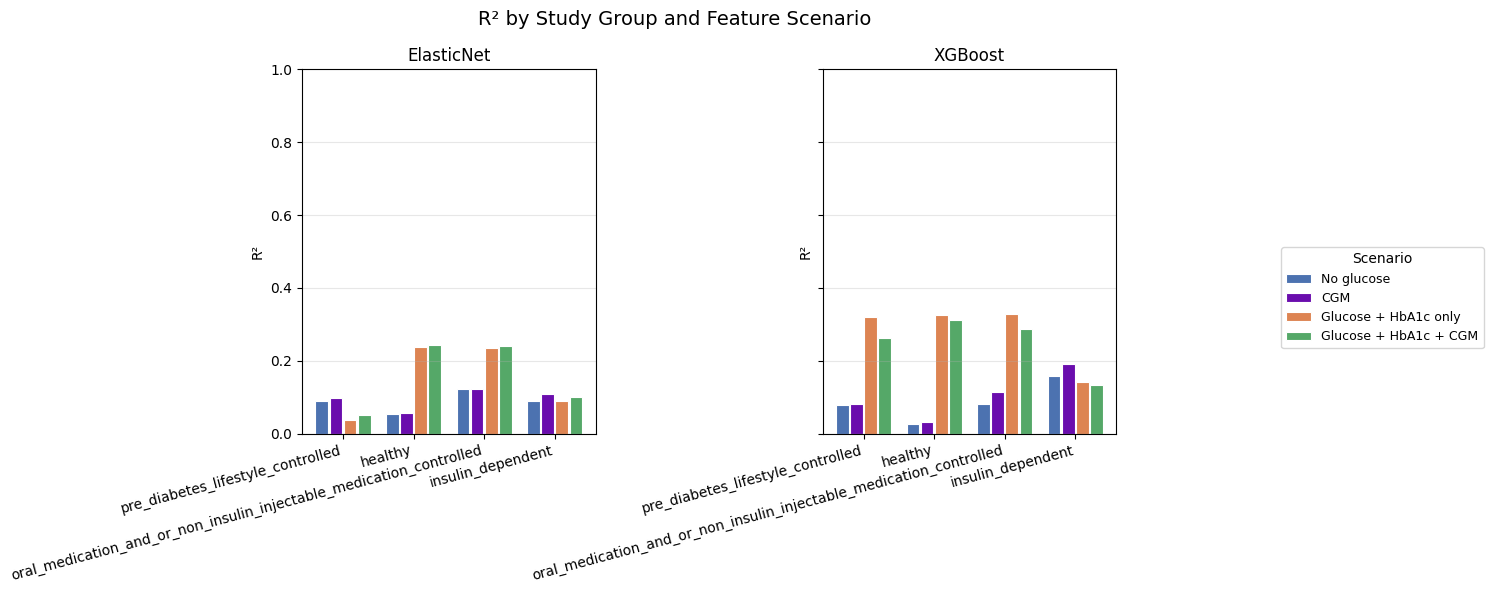

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

comp = pd.read_csv('ablation_results_minimal/ablation_comparison.csv')

SCENARIO_LABELS = {
    '1_no_glucose': 'base_model',
    '2_cgm_only_remove_labs': 'CGM',
    '3_labs_only_remove_cgm': 'Glucose + HbA1c only',
    '4_labs_plus_cgm': 'Glucose + HbA1c + CGM',
}
comp['scenario_label'] = comp['scenario'].map(SCENARIO_LABELS)

study_groups = comp['study_group'].unique()
scenarios = list(SCENARIO_LABELS.values())
color_map = dict(zip(scenarios, ['#4C72B0', '#6A0DAD', '#DD8452', '#55A868']))

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

n_scenarios = len(scenarios)
group_width = 0.8
bar_width = group_width / n_scenarios

for ax, model, r2_col, se_col in zip(
    axes,
    ['ElasticNet', 'XGBoost'],
    ['enet_r2', 'xgb_r2'],
    ['enet_r2_se', 'xgb_r2_se']
):
    x = np.arange(len(study_groups))

    # dodge bars side-by-side per scenario so every color stays fully visible,
    # even when R2 values are nearly identical across scenarios
    for i, scenario in enumerate(scenarios):
        offset = (i - (n_scenarios - 1) / 2) * bar_width
        sub = comp[comp['scenario_label'] == scenario].set_index('study_group').reindex(study_groups)
        ax.bar(
            x + offset, sub[r2_col], width=bar_width * 0.9,
            color=color_map[scenario],
            edgecolor='white', linewidth=0.8,
            label=scenario
        )

    ax.set_xticks(x)
    ax.set_xticklabels(study_groups, rotation=15, ha='right')
    ax.set_ylim(0, 1)
    ax.set_ylabel('R²')
    ax.set_title(model)
    ax.grid(axis='y', alpha=0.3, zorder=0)

# shared legend, placed outside the plotting area
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    title='Scenario',
    loc='center left',
    bbox_to_anchor=(1.0, 0.5),
    fontsize=9
)

plt.suptitle('R² by Study Group and Feature Scenario', fontsize=14)
plt.tight_layout(rect=[0, 0, 0.88, 1])
plt.savefig('ablation_results/r2_comparison_overlap.png', dpi=150, bbox_inches='tight')
plt.show()